In [1]:
import importlib
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Make src/ importable from notebooks/
sys.path.insert(0, str(Path.cwd().parent))

import src.data_loader
import src.features
import src.train
import src.baselines

importlib.reload(src.data_loader)
importlib.reload(src.features)
importlib.reload(src.train)
importlib.reload(src.baselines)

from src.data_loader import (
    fetch_dam_prices,
    fetch_load_forecast,
    fetch_renewable_forecast,
    fetch_all_inputs,
    load_prices,
    save_prices,
)
from src.features import (
    build_supervised_dataset,
    make_calendar_features,
    make_forecast_time_features,
    make_target_relative_lags,
    make_exogenous_target_features,
    make_exogenous_forecast_time_features,
    hours_to_target,
)
from src.train import (
    train_per_horizon_models,
    predict_next_day,
    temporal_split,
)
from src.baselines import evaluate_naive_baselines

print("Imports OK.")

Imports OK.


In [2]:
load_dotenv(override=True)
token = os.getenv("ENTSOE_API_TOKEN")

if token:
    print(f"Token loaded ✓  (length: {len(token)}, prefix: {token[:6]}…)")
else:
    raise RuntimeError(
        "ENTSOE_API_TOKEN not found. Check that .env exists in the project root."
    )

Token loaded ✓  (length: 36, prefix: e66909…)


In [3]:
# Data window
DATA_START = pd.Timestamp("2023-01-01", tz="Europe/Athens")
DATA_END = pd.Timestamp("2024-07-01", tz="Europe/Athens")

# Forecasting setup
GATE_CLOSURE_HOUR = 12
HORIZONS = tuple(range(0, 24))
SAME_HOUR_LAG_DAYS = (1, 2, 7)
CONTEXT_WINDOW = 1
TEST_DAYS = 30

# Cache file
CACHE_PATH = Path("../data/raw/greek_inputs_2023_2024H1.csv")

print(f"Data range:        {DATA_START}  →  {DATA_END}")
print(f"Gate closure hour: {GATE_CLOSURE_HOUR}:00")
print(f"Horizons:          {HORIZONS[0]}..{HORIZONS[-1]} (target hours of next day)")
print(f"Same-hour lags:    {SAME_HOUR_LAG_DAYS} days back")
print(f"Context window:    ±{CONTEXT_WINDOW} hours")
print(f"Test set size:     {TEST_DAYS} days")
print(f"Cache path:        {CACHE_PATH}")

Data range:        2023-01-01 00:00:00+02:00  →  2024-07-01 00:00:00+03:00
Gate closure hour: 12:00
Horizons:          0..23 (target hours of next day)
Same-hour lags:    (1, 2, 7) days back
Context window:    ±1 hours
Test set size:     30 days
Cache path:        ..\data\raw\greek_inputs_2023_2024H1.csv


In [4]:
if CACHE_PATH.exists():
    inputs_raw = pd.read_csv(CACHE_PATH, index_col=0)
    inputs_raw.index = pd.to_datetime(inputs_raw.index, utc=True).tz_convert("Europe/Athens")
    print(f"Loaded {len(inputs_raw)} rows from cache.")
else:
    print("Cache not found, fetching from ENTSO-E (1-2 minutes)…")
    inputs_raw = fetch_all_inputs(DATA_START, DATA_END, country_code="GR")

    # Write with timestamps normalized to UTC, to avoid mixed-offset CSV
    to_save = inputs_raw.copy()
    to_save.index = to_save.index.tz_convert("UTC")
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    to_save.to_csv(CACHE_PATH)
    print(f"Fetched and cached {len(inputs_raw)} rows.")

print(f"\nIndex type: {type(inputs_raw.index).__name__}")
print(f"Index tz:   {inputs_raw.index.tz}")
print(f"Columns:    {list(inputs_raw.columns)}")
print(f"Range:      {inputs_raw.index.min()}  →  {inputs_raw.index.max()}")
inputs_raw.head()

Loaded 13128 rows from cache.

Index type: DatetimeIndex
Index tz:   Europe/Athens
Columns:    ['price_eur_mwh', 'load_forecast_mw', 'solar', 'wind_onshore']
Range:      2023-01-01 00:00:00+02:00  →  2024-07-01 00:00:00+03:00


,price_eur_mwh,load_forecast_mw,solar,wind_onshore
2023-01-01 00:00:00+02:00,210.05,4269.0,0.0,495.0
2023-01-01 01:00:00+02:00,230.90,4008.0,0.0,518.0
2023-01-01 02:00:00+02:00,268.19,3888.0,0.0,560.0
2023-01-01 03:00:00+02:00,229.58,3760.0,0.0,603.0
2023-01-01 04:00:00+02:00,235.98,3703.0,0.0,649.0


In [5]:
print("Missing values per column (before ffill):")
print(inputs_raw.isna().sum())

inputs = inputs_raw.ffill()

print(f"\nMissing values per column (after ffill):")
print(inputs.isna().sum())

# Drop any leading rows where ffill couldn't fill (no prior value to carry)
inputs = inputs.dropna()
print(f"\nFinal shape after dropping leading NaN rows: {inputs.shape}")

Missing values per column (before ffill):
price_eur_mwh       0
load_forecast_mw    2
solar               2
wind_onshore        2
dtype: int64

Missing values per column (after ffill):
price_eur_mwh       0
load_forecast_mw    0
solar               0
wind_onshore        0
dtype: int64

Final shape after dropping leading NaN rows: (13128, 4)


In [6]:
prices = inputs["price_eur_mwh"].copy()
exog_cols = [c for c in inputs.columns if c != "price_eur_mwh"]
exog = inputs[exog_cols].copy()

print(f"Prices: {len(prices)} hourly values, range {prices.min():.1f}–{prices.max():.1f} EUR/MWh")
print(f"Exog columns: {list(exog.columns)}")
print()
exog.describe().T

Prices: 13128 hourly values, range -1.0–384.8 EUR/MWh
Exog columns: ['load_forecast_mw', 'solar', 'wind_onshore']



,count,mean,std,min,25%,50%,75%,max
load_forecast_mw,13128.0,5440.509141,1181.342638,230.0,4558.0,5331.0,6088.00,10323.0
solar,13128.0,932.484004,1279.087257,0.0,0.0,40.0,1808.25,5052.0
wind_onshore,13128.0,1192.201097,796.818171,46.0,525.0,1003.0,1704.00,3336.0


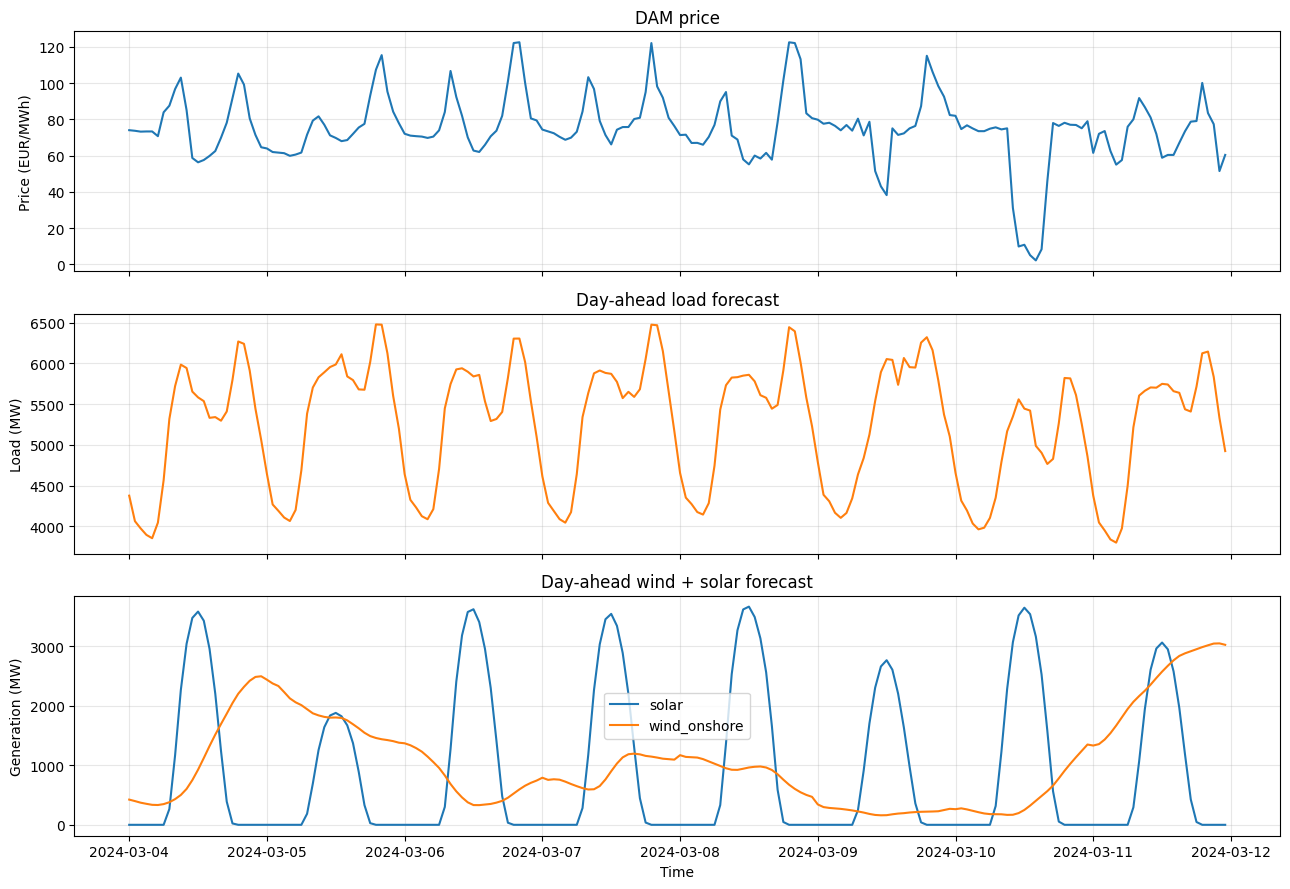

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

window = inputs.loc["2024-03-04":"2024-03-11"]

axes[0].plot(window.index, window["price_eur_mwh"], color="C0")
axes[0].set_ylabel("Price (EUR/MWh)")
axes[0].set_title("DAM price")
axes[0].grid(alpha=0.3)

axes[1].plot(window.index, window["load_forecast_mw"], color="C1")
axes[1].set_ylabel("Load (MW)")
axes[1].set_title("Day-ahead load forecast")
axes[1].grid(alpha=0.3)

renew_cols = [c for c in window.columns if c not in ("price_eur_mwh", "load_forecast_mw")]
for c in renew_cols:
    axes[2].plot(window.index, window[c], label=c)
axes[2].set_ylabel("Generation (MW)")
axes[2].set_title("Day-ahead wind + solar forecast")
axes[2].set_xlabel("Time")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

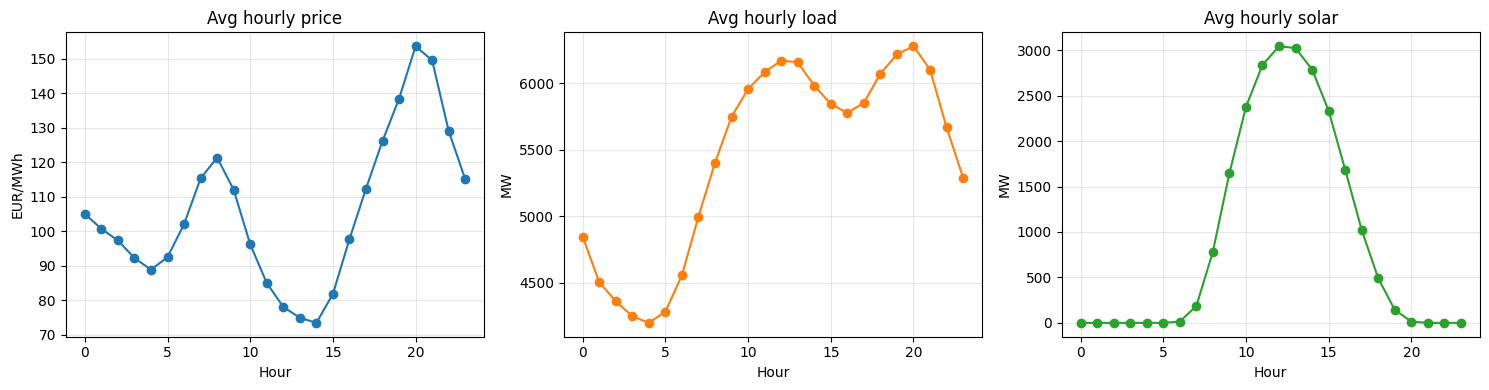

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

prices.groupby(prices.index.hour).mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Avg hourly price")
axes[0].set_ylabel("EUR/MWh")
axes[0].set_xlabel("Hour")
axes[0].grid(alpha=0.3)

inputs["load_forecast_mw"].groupby(inputs.index.hour).mean().plot(ax=axes[1], marker="o", color="C1")
axes[1].set_title("Avg hourly load")
axes[1].set_ylabel("MW")
axes[1].set_xlabel("Hour")
axes[1].grid(alpha=0.3)

if "solar" in inputs.columns:
    inputs["solar"].groupby(inputs.index.hour).mean().plot(ax=axes[2], marker="o", color="C2")
    axes[2].set_title("Avg hourly solar")
    axes[2].set_ylabel("MW")
    axes[2].set_xlabel("Hour")
    axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
X, y, meta = build_supervised_dataset(
    prices,
    exog=exog,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Forecast days: {meta['forecast_time'].nunique()}")
print(f"Number of features: {X.shape[1]}")

X shape: (13105, 39)
y shape: (13105,)
Forecast days: 547
Number of features: 39


In [10]:
X

,ft_price_minus_0h,ft_price_minus_1h,ft_price_minus_2h,ft_price_minus_3h,ft_mean_24h,ft_std_24h,ft_max_24h,ft_min_24h,ft_mean_168h,ft_std_168h,...,target_is_holiday,target_hour_sin,target_hour_cos,target_dow_sin,target_dow_cos,target_load_forecast_mw,target_solar,target_wind_onshore,target_net_load_mw,horizon
0,168.50,177.25,186.47,186.47,218.218462,29.744306,268.19,168.50,218.218462,29.744306,...,0,0.000000,1.000000,0.000000,1.000000,3990.0,0.0,648.0,3342.0,0
1,188.89,196.23,203.99,231.00,241.542500,82.162184,363.15,81.95,233.347568,68.813028,...,0,0.000000,1.000000,0.781831,0.623490,4551.0,0.0,129.0,4422.0,0
2,180.20,191.58,198.49,269.99,280.403750,69.600953,363.77,172.78,251.861475,72.355751,...,0,0.000000,1.000000,0.974928,-0.222521,4663.0,0.0,251.0,4412.0,0
3,173.50,183.83,191.22,217.72,232.222500,75.498526,369.17,130.00,246.316353,73.344007,...,0,0.000000,1.000000,0.433884,-0.900969,4764.0,0.0,879.0,3885.0,0
4,184.38,192.94,242.65,264.11,224.702500,81.861826,362.31,100.00,241.557339,75.445544,...,1,0.000000,1.000000,-0.433884,-0.900969,4702.0,0.0,583.0,4119.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13100,78.56,78.61,90.41,111.01,129.820417,57.018627,300.00,73.14,104.534940,46.346404,...,0,-0.258819,0.965926,0.974928,-0.222521,7333.0,0.0,1330.0,6003.0,23
13101,93.42,96.54,101.76,121.10,129.178333,60.859356,320.00,86.02,108.900833,50.471372,...,0,-0.258819,0.965926,0.433884,-0.900969,7071.0,0.0,646.0,6425.0,23
13102,82.14,86.52,89.47,115.00,124.130000,60.697048,319.29,82.14,112.791369,52.744476,...,0,-0.258819,0.965926,-0.433884,-0.900969,6954.0,0.0,2303.0,4651.0,23
13103,45.98,59.11,63.37,84.52,118.837083,67.266814,324.95,45.98,114.621607,56.865058,...,0,-0.258819,0.965926,-0.974928,-0.222521,6679.0,0.0,2629.0,4050.0,23


In [11]:
ft_cols     = [c for c in X.columns if c.startswith("ft_")]
tr_cols     = [c for c in X.columns if c.startswith("tr_")]
target_cols = [c for c in X.columns if c.startswith("target_")]
other       = [c for c in X.columns if c not in ft_cols + tr_cols + target_cols]

print(f"Forecast-time features ({len(ft_cols)}):")
for c in ft_cols: print(f"  {c}")
print(f"\nTarget-relative price lags ({len(tr_cols)}):")
for c in tr_cols: print(f"  {c}")
print(f"\nTarget-time features (calendar + exog) ({len(target_cols)}):")
for c in target_cols: print(f"  {c}")
print(f"\nOther: {other}")

Forecast-time features (16):
  ft_price_minus_0h
  ft_price_minus_1h
  ft_price_minus_2h
  ft_price_minus_3h
  ft_mean_24h
  ft_std_24h
  ft_max_24h
  ft_min_24h
  ft_mean_168h
  ft_std_168h
  ft_max_168h
  ft_min_168h
  ft_load_forecast_mw
  ft_solar
  ft_wind_onshore
  ft_net_load_mw

Target-relative price lags (9):
  tr_lag_d1_k-1
  tr_lag_d1_k+0
  tr_lag_d1_k+1
  tr_lag_d2_k-1
  tr_lag_d2_k+0
  tr_lag_d2_k+1
  tr_lag_d7_k-1
  tr_lag_d7_k+0
  tr_lag_d7_k+1

Target-time features (calendar + exog) (13):
  target_hour
  target_dow
  target_month
  target_is_weekend
  target_is_holiday
  target_hour_sin
  target_hour_cos
  target_dow_sin
  target_dow_cos
  target_load_forecast_mw
  target_solar
  target_wind_onshore
  target_net_load_mw

Other: ['horizon']


In [12]:
print("NaN pattern in tr_* features by horizon (after warm-up).\n")
print(f"{'horizon':>7} | {'NaN tr_* columns':<55} | n_NaN")
print("-" * 80)

for h in sorted(meta["horizon"].unique()):
    mask = (meta["horizon"] == h)
    rows_for_h = X[mask].reset_index(drop=True)
    sample = rows_for_h.iloc[10]
    nan_cols = [c for c in tr_cols if pd.isna(sample[c])]
    label = ", ".join(c.replace("tr_lag_", "") for c in nan_cols) or "(none)"
    print(f"{h:>7} | {label:<55} | {len(nan_cols)}")

NaN pattern in tr_* features by horizon (after warm-up).

horizon | NaN tr_* columns                                        | n_NaN
--------------------------------------------------------------------------------
      0 | (none)                                                  | 0
      1 | (none)                                                  | 0
      2 | (none)                                                  | 0
      3 | (none)                                                  | 0
      4 | (none)                                                  | 0
      5 | (none)                                                  | 0
      6 | (none)                                                  | 0
      7 | (none)                                                  | 0
      8 | (none)                                                  | 0
      9 | (none)                                                  | 0
     10 | (none)                                                  | 0
     11 | (none) 

In [14]:
result_exog = train_per_horizon_models(
    prices,
    exog=exog,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
    test_days=TEST_DAYS,
)

print(f"Trained {len(result_exog.models)} per-horizon models with exogenous features.")
print(f"Overall test MAE:  {result_exog.overall_test_mae:.2f} EUR/MWh")
print(f"Overall test RMSE: {result_exog.overall_test_rmse:.2f} EUR/MWh")

Trained 24 per-horizon models with exogenous features.
Overall test MAE:  22.01 EUR/MWh
Overall test RMSE: 27.37 EUR/MWh


In [15]:
result_priceonly = train_per_horizon_models(
    prices,
    exog=None,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
    test_days=TEST_DAYS,
)

print(f"Price-only LightGBM:")
print(f"  Overall test MAE:  {result_priceonly.overall_test_mae:.2f} EUR/MWh")
print(f"  Number of features: {len(result_priceonly.feature_names)}")

Price-only LightGBM:
  Overall test MAE:  21.52 EUR/MWh
  Number of features: 30


In [16]:
X_full, y_full, meta_full = build_supervised_dataset(
    prices, exog=exog,
    gate_closure_hour=GATE_CLOSURE_HOUR,
    horizons=HORIZONS,
    same_hour_lag_days=SAME_HOUR_LAG_DAYS,
    context_window=CONTEXT_WINDOW,
)
_, _, _, _, y_te_full, m_te_full = temporal_split(X_full, y_full, meta_full, test_days=TEST_DAYS)

naive_metrics = evaluate_naive_baselines(
    prices, m_te_full, y_te_full, gate_closure_hour=GATE_CLOSURE_HOUR
)

naive_weights = naive_metrics["n_test"]
overall_naive = {
    col: (naive_metrics[col] * naive_weights).sum() / naive_weights.sum()
    for col in ["mae_yesterday", "mae_last_week", "mae_average"]
}

for label, val in overall_naive.items():
    print(f"  {label:20s} = {val:.2f}")

  mae_yesterday        = 25.91
  mae_last_week        = 22.30
  mae_average          = 20.72


In [17]:
print("=" * 70)
print(" Model comparison — overall test MAE (lower is better)")
print("=" * 70)

models_summary = [
    ("LightGBM + exog (load + renewables)", result_exog.overall_test_mae),
    ("LightGBM (price only)",               result_priceonly.overall_test_mae),
    ("Naïve average (yesterday + last wk)", overall_naive["mae_average"]),
    ("Naïve last week",                      overall_naive["mae_last_week"]),
    ("Naïve yesterday",                      overall_naive["mae_yesterday"]),
]
for label, val in models_summary:
    print(f"  {label:40s}  {val:7.2f} EUR/MWh")

print("=" * 70)

best_naive = min(overall_naive.values())
gain_vs_naive = (best_naive - result_exog.overall_test_mae) / best_naive * 100
gain_vs_priceonly = (result_priceonly.overall_test_mae - result_exog.overall_test_mae) / result_priceonly.overall_test_mae * 100

print(f"\nLightGBM+exog vs best naïve:  {gain_vs_naive:+.1f}%  (positive = LGBM better)")
print(f"LightGBM+exog vs price-only:  {gain_vs_priceonly:+.1f}%  (gain from exog features)")

 Model comparison — overall test MAE (lower is better)
  LightGBM + exog (load + renewables)         22.01 EUR/MWh
  LightGBM (price only)                       21.52 EUR/MWh
  Naïve average (yesterday + last wk)         20.72 EUR/MWh
  Naïve last week                             22.30 EUR/MWh
  Naïve yesterday                             25.91 EUR/MWh

LightGBM+exog vs best naïve:  -6.2%  (positive = LGBM better)
LightGBM+exog vs price-only:  -2.3%  (gain from exog features)


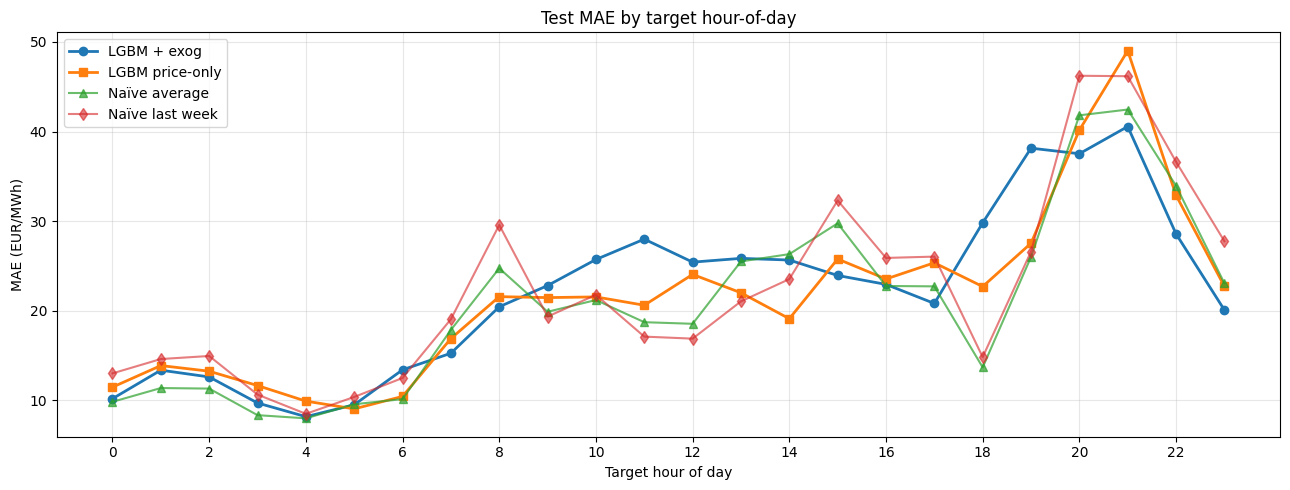

In [18]:
fig, ax = plt.subplots(figsize=(13, 5))

m_exog = result_exog.metrics_per_horizon.set_index("horizon")
m_priceonly = result_priceonly.metrics_per_horizon.set_index("horizon")
m_naive = naive_metrics.set_index("horizon")

ax.plot(m_exog.index,      m_exog["mae"],           marker="o", label="LGBM + exog",     linewidth=2)
ax.plot(m_priceonly.index, m_priceonly["mae"],      marker="s", label="LGBM price-only", linewidth=2)
ax.plot(m_naive.index,     m_naive["mae_average"],  marker="^", label="Naïve average",   alpha=0.7)
ax.plot(m_naive.index,     m_naive["mae_last_week"],marker="d", label="Naïve last week", alpha=0.6)

ax.set_title("Test MAE by target hour-of-day")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_xlabel("Target hour of day")
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

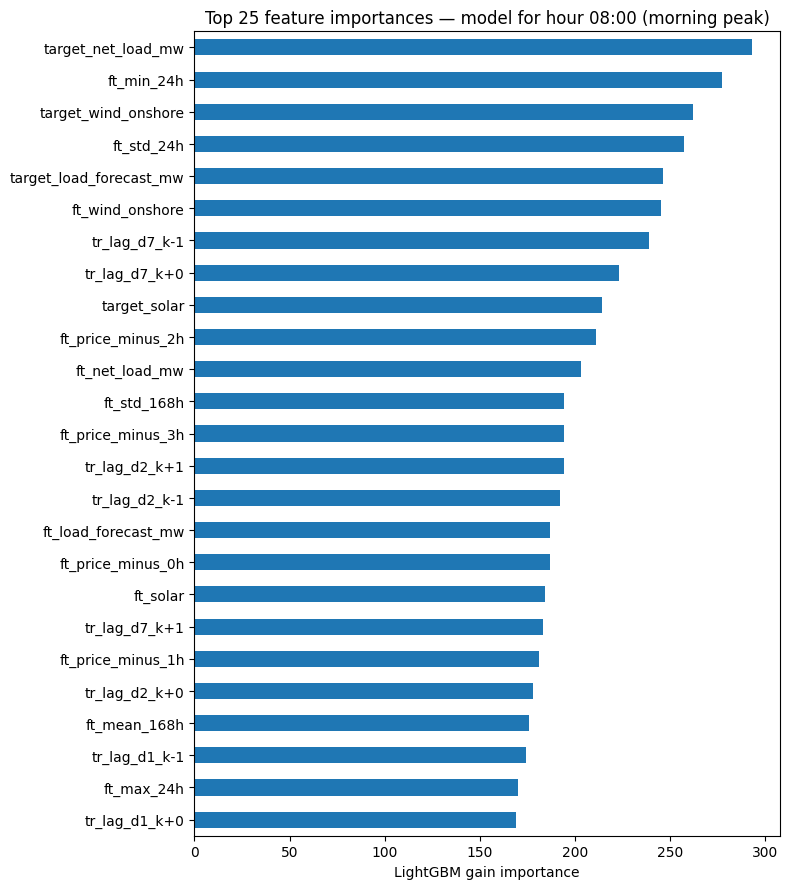

In [19]:
model_h8 = result_exog.models[8]
importances = pd.Series(
    model_h8.feature_importances_,
    index=result_exog.feature_names,
).sort_values(ascending=True)

top25 = importances.tail(25)

fig, ax = plt.subplots(figsize=(8, 9))
top25.plot.barh(ax=ax)
ax.set_title("Top 25 feature importances — model for hour 08:00 (morning peak)")
ax.set_xlabel("LightGBM gain importance")
plt.tight_layout()
plt.show()

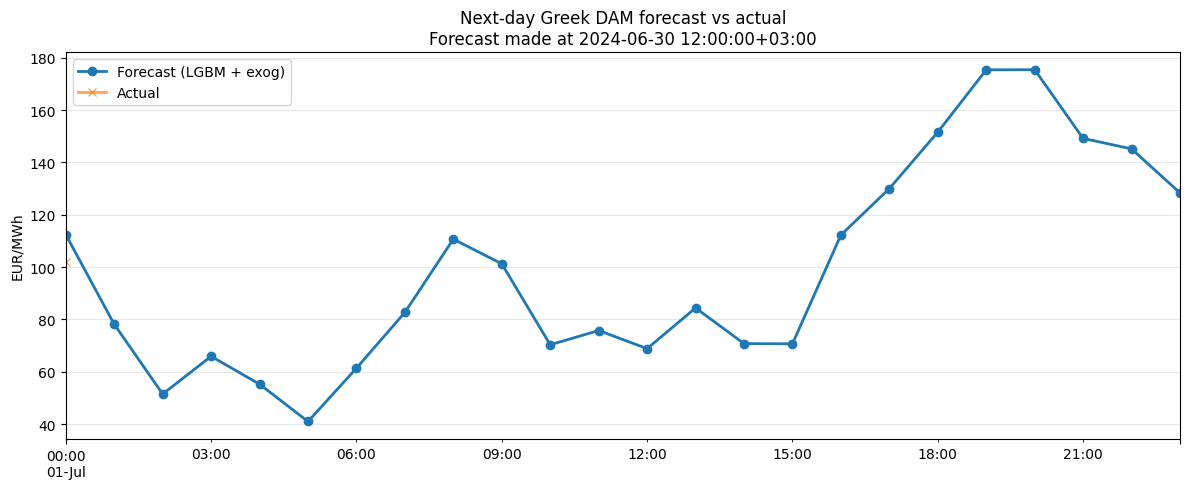

This day's MAE: 10.30 EUR/MWh


In [20]:
forecast = predict_next_day(result_exog, prices, exog=exog)
actuals = prices.reindex(forecast.index)

fig, ax = plt.subplots(figsize=(12, 5))
forecast.plot(ax=ax, marker="o", label="Forecast (LGBM + exog)", linewidth=2)
actuals.plot(ax=ax, marker="x", label="Actual", linewidth=2, alpha=0.7)
forecast_made_at = forecast.index.min() - pd.Timedelta(hours=hours_to_target(GATE_CLOSURE_HOUR, 0))
ax.set_title(f"Next-day Greek DAM forecast vs actual\nForecast made at {forecast_made_at}")
ax.set_ylabel("EUR/MWh")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

mae_day = (forecast - actuals).abs().mean()
print(f"This day's MAE: {mae_day:.2f} EUR/MWh")

In [21]:
print("=== Index alignment check ===\n")

prices_idx = prices.index
exog_idx = exog.index

print(f"Prices: {len(prices_idx)} rows, range {prices_idx.min()} → {prices_idx.max()}")
print(f"Exog:   {len(exog_idx)} rows, range {exog_idx.min()} → {exog_idx.max()}")
print(f"Same length:        {len(prices_idx) == len(exog_idx)}")
print(f"Indices identical:  {prices_idx.equals(exog_idx)}")

if not prices_idx.equals(exog_idx):
    only_in_prices = prices_idx.difference(exog_idx)
    only_in_exog = exog_idx.difference(prices_idx)
    print(f"  Timestamps only in prices: {len(only_in_prices)}")
    print(f"  Timestamps only in exog:   {len(only_in_exog)}")
    if len(only_in_prices) > 0:
        print(f"  First few price-only:  {only_in_prices[:5].tolist()}")
    if len(only_in_exog) > 0:
        print(f"  First few exog-only:   {only_in_exog[:5].tolist()}")

=== Index alignment check ===

Prices: 13128 rows, range 2023-01-01 00:00:00+02:00 → 2024-07-01 00:00:00+03:00
Exog:   13128 rows, range 2023-01-01 00:00:00+02:00 → 2024-07-01 00:00:00+03:00
Same length:        True
Indices identical:  True


=== Load vs price correlation ===

Same-hour Pearson correlation (price vs load): 0.241
Daily-average Pearson correlation:             0.251


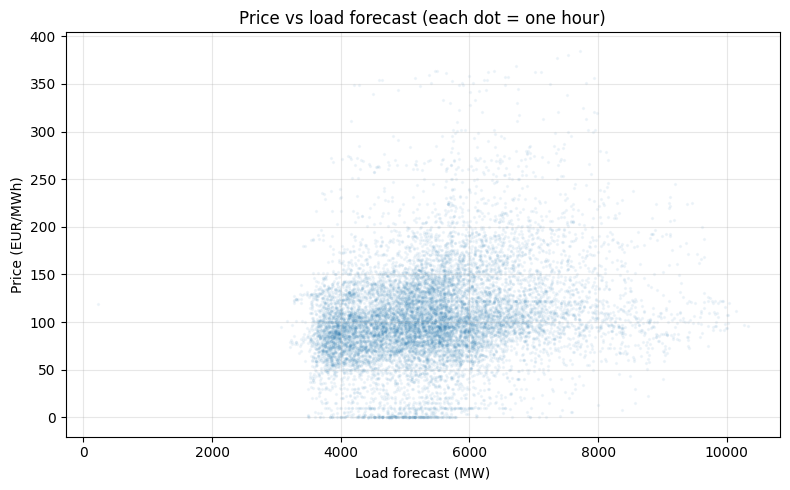

In [22]:
import numpy as np

print("=== Load vs price correlation ===\n")

aligned = pd.concat([
    prices.rename("price"),
    exog["load_forecast_mw"].rename("load")
], axis=1).dropna()

# Hour-by-hour correlations
print(f"Same-hour Pearson correlation (price vs load): {aligned['price'].corr(aligned['load']):.3f}")

# Daily-average correlations
daily = aligned.resample("D").mean()
print(f"Daily-average Pearson correlation:             {daily['price'].corr(daily['load']):.3f}")

# Quick scatter
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(aligned["load"], aligned["price"], alpha=0.05, s=2)
ax.set_xlabel("Load forecast (MW)")
ax.set_ylabel("Price (EUR/MWh)")
ax.set_title("Price vs load forecast (each dot = one hour)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
print("=== Net load sanity check ===\n")
print(exog.describe().T[["min", "mean", "max"]])
print()

if "load_forecast_mw" in exog.columns:
    renew_cols = [c for c in exog.columns if c != "load_forecast_mw"]
    net_load = exog["load_forecast_mw"] - exog[renew_cols].sum(axis=1)
    print(f"Net load: min={net_load.min():.0f}, mean={net_load.mean():.0f}, max={net_load.max():.0f}")
    print(f"Negative values: {(net_load < 0).sum()} (this should be very few or zero)")

=== Net load sanity check ===

                    min         mean      max
load_forecast_mw  230.0  5440.509141  10323.0
solar               0.0   932.484004   5052.0
wind_onshore       46.0  1192.201097   3336.0

Net load: min=-2522, mean=3316, max=8766
Negative values: 273 (this should be very few or zero)


In [24]:
print("=== Sanity of exogenous features in X ===\n")
exog_in_X = [c for c in X.columns if any(k in c for k in ["load", "solar", "wind", "net_load"])]
print(f"Exog columns in X: {exog_in_X}")
print()
print(X[exog_in_X].describe().T[["min", "mean", "max"]])
print()
print(f"NaN count in exog cols:")
print(X[exog_in_X].isna().sum())

=== Sanity of exogenous features in X ===

Exog columns in X: ['ft_load_forecast_mw', 'ft_solar', 'ft_wind_onshore', 'ft_net_load_mw', 'target_load_forecast_mw', 'target_solar', 'target_wind_onshore', 'target_net_load_mw']

                            min         mean      max
ft_load_forecast_mw      3716.0  6167.405723   9832.0
ft_solar                  460.0  3040.398474   4926.0
ft_wind_onshore            46.0  1199.411522   3207.0
ft_net_load_mw          -2310.0  1927.595727   6025.0
target_load_forecast_mw   230.0  5441.781686  10323.0
target_solar                0.0   932.835864   5052.0
target_wind_onshore        46.0  1193.102022   3336.0
target_net_load_mw      -2522.0  3315.843800   8766.0

NaN count in exog cols:
ft_load_forecast_mw        0
ft_solar                   0
ft_wind_onshore            0
ft_net_load_mw             0
target_load_forecast_mw    0
target_solar               0
target_wind_onshore        0
target_net_load_mw         0
dtype: int64


In [25]:
import pandas as pd

# Sample one summer noon hour and look at the values
sample_time = pd.Timestamp("2024-06-15 12:00", tz="Europe/Athens")
print(f"Values at {sample_time}:")
print(f"  Load forecast:  {exog.loc[sample_time, 'load_forecast_mw']:.0f} MW")
print(f"  Solar forecast: {exog.loc[sample_time, 'solar']:.0f} MW")
print(f"  Wind forecast:  {exog.loc[sample_time, 'wind_onshore']:.0f} MW")
print(f"  Sum renewables: {exog.loc[sample_time, 'solar'] + exog.loc[sample_time, 'wind_onshore']:.0f} MW")
print()

# Greek installed capacities (2024)
print("Greek installed capacity (mid-2024 reference):")
print(f"  Solar:    ~7,000-8,000 MW")
print(f"  Wind:     ~5,000 MW")
print(f"  Peak load: ~10,500 MW")
print()

# Distribution of solar at noon hours
solar_noon = exog["solar"][exog.index.hour == 12]
print(f"Solar at 12:00 across all days:")
print(f"  Count:  {len(solar_noon)}")
print(f"  Min:    {solar_noon.min():.0f}")
print(f"  Median: {solar_noon.median():.0f}")
print(f"  Max:    {solar_noon.max():.0f}")

Values at 2024-06-15 12:00:00+03:00:
  Load forecast:  7232 MW
  Solar forecast: 4768 MW
  Wind forecast:  390 MW
  Sum renewables: 5158 MW

Greek installed capacity (mid-2024 reference):
  Solar:    ~7,000-8,000 MW
  Wind:     ~5,000 MW
  Peak load: ~10,500 MW

Solar at 12:00 across all days:
  Count:  547
  Min:    460
  Median: 3097
  Max:    4926


In [26]:
print("=== Frequency check ===\n")

# Time delta between consecutive observations
deltas = pd.Series(exog.index.to_series().diff().dropna().value_counts())
print(f"Time delta distribution between rows:")
print(deltas.head(10))
print()

# If the source was 15-min and entsoe-py resampled, we'd see clean 1h gaps everywhere
# If it kept 15-min, we'd see 15-min gaps
expected = pd.Timedelta(hours=1)
all_hourly = (exog.index.to_series().diff().dropna() == expected).all()
print(f"All deltas are exactly 1 hour: {all_hourly}")

print("\n=== Negative net load investigation ===\n")
renew_cols = [c for c in exog.columns if c != "load_forecast_mw"]
net_load = exog["load_forecast_mw"] - exog[renew_cols].sum(axis=1)

neg_mask = net_load < 0
print(f"Total negative-net-load hours: {neg_mask.sum()}")
print(f"\nDistribution by hour-of-day:")
print(net_load[neg_mask].groupby(net_load[neg_mask].index.hour).count())

print(f"\nSample of worst offenders:")
worst = net_load.nsmallest(5)
for ts in worst.index:
    print(f"  {ts}:  load={exog.loc[ts, 'load_forecast_mw']:.0f}  "
          f"solar={exog.loc[ts, 'solar']:.0f}  "
          f"wind={exog.loc[ts, 'wind_onshore']:.0f}  "
          f"=> net={net_load.loc[ts]:.0f}")

=== Frequency check ===

Time delta distribution between rows:
0 days 01:00:00    13127
Name: count, dtype: int64

All deltas are exactly 1 hour: True

=== Negative net load investigation ===

Total negative-net-load hours: 273

Distribution by hour-of-day:
0      1
8      1
9      7
10    20
11    38
12    44
13    45
14    47
15    37
16    23
17    10
dtype: int64

Sample of worst offenders:
  2024-05-05 13:00:00+03:00:  load=4276  solar=4576  wind=2222  => net=-2522
  2024-04-28 14:00:00+03:00:  load=4752  solar=4482  wind=2713  => net=-2443
  2024-05-05 14:00:00+03:00:  load=4052  solar=4351  wind=2069  => net=-2368
  2024-04-28 15:00:00+03:00:  load=4424  solar=4070  wind=2713  => net=-2359
  2024-04-12 12:00:00+03:00:  load=5225  solar=4385  wind=3150  => net=-2310


In [29]:
from entsoe import EntsoeRawClient

raw_client = EntsoeRawClient(api_key=token)
test_start = pd.Timestamp("2024-06-01", tz="Europe/Athens")
test_end = pd.Timestamp("2024-06-03", tz="Europe/Athens")

# Get raw XML for load forecast
xml = raw_client.query_load_forecast("GR", start=test_start, end=test_end)
print(xml[:3000])  # first 3000 characters

<?xml version="1.0" encoding="utf-8"?>
<GL_MarketDocument xmlns="urn:iec62325.351:tc57wg16:451-6:generationloaddocument:3:0">
  <mRID>bd3ab7d21e6045b89f7aa0c1af049364</mRID>
  <revisionNumber>1</revisionNumber>
  <type>A65</type>
  <process.processType>A01</process.processType>
  <sender_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</sender_MarketParticipant.mRID>
  <sender_MarketParticipant.marketRole.type>A32</sender_MarketParticipant.marketRole.type>
  <receiver_MarketParticipant.mRID codingScheme="A01">10X1001A1001A450</receiver_MarketParticipant.mRID>
  <receiver_MarketParticipant.marketRole.type>A33</receiver_MarketParticipant.marketRole.type>
  <createdDateTime>2026-04-29T12:11:25Z</createdDateTime>
  <time_Period.timeInterval>
    <start>2024-05-31T21:00Z</start>
    <end>2024-06-02T21:00Z</end>
  </time_Period.timeInterval>
    <TimeSeries>
      <mRID>1</mRID>
      <businessType>A04</businessType>
      <objectAggregation>A01</objectAggregation>
      <outBiddin